In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
import xml.etree.ElementTree as ET
from datetime import datetime
import warnings

warnings.simplefilter('ignore')

In [3]:
def parse_sms_backup(xml_path:str) -> pd.DataFrame:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    records = []
    for sms in root.findall('sms'):
        body = sms.get('body', '')
        date_sms=int(sms.get('date', 0))

        if 'M-PESA' not in body.upper():
            continue

        records.append({
            'body': body,
            'timestamp': datetime.fromtimestamp(date_sms / 1000)
        })

    df = pd.DataFrame(records)
    print(f"✔️Found {len(df)} M-pesa SMSes")

    return df



In [5]:
df_raw = parse_sms_backup("sms-20260520144009.xml")
df_raw.head()

✔️Found 4300 M-pesa SMSes


,body,timestamp
0,QAA7EYUOVT Confirmed. Ksh200.00 paid to RAPHAE...,2022-01-10 17:41:48.209
1,"QCJ6WSQY1A Confirmed. Ksh1,950.00 sent to Equi...",2022-03-19 08:56:05.063
2,QEA3RXICDP Confirmed. Ksh100.00 sent to ELIZAB...,2022-05-10 18:56:28.832
3,QEA3RXICDP Confirmed. Ksh100.00 sent to ELIZAB...,2022-05-10 19:20:32.346
4,QED4XRFH98 Confirmed. Ksh250.00 paid to RAPHAE...,2022-05-13 18:35:03.111


In [7]:
patterns = {

    # P2P sent — with or without phone number
    # e.g. "Ksh100.00 sent to ELIZABETH NJOKA 0720404104 on..."
    # e.g. "Ksh50.00 sent to SUSAN NJERI on..."
    'sent': re.compile(
        r'Confirmed\.\s*Ksh\s*([\d,]+\.?\d*)\s+sent to\s+(.+?)\s+(\d{9,12})?\s*on\s+[\d/]+\s+at\s+[\d:]+\s*[AP]M.*?New M-PESA balance is Ksh\s*([\d,]+\.?\d*)',
        re.IGNORECASE | re.DOTALL
    ),

    # Paybill with account number
    # e.g. "Ksh1,950.00 sent to Equity Paybill Account for account 0766931528 on..."
    # e.g. "Ksh1,150.00 sent to Co-operative Bank Money Transfer for account 49007 on..."
    'paybill': re.compile(
        r'Confirmed\.\s*Ksh\s*([\d,]+\.?\d*)\s+sent to\s+(.+?)\s+for account\s+([\w\d]+)\s+on\s+[\d/]+\s+at\s+[\d:]+\s*[AP]M.*?New M-PESA balance is Ksh\s*([\d,]+\.?\d*)',
        re.IGNORECASE | re.DOTALL
    ),

    # Till number payment — business name, no account number
    # e.g. "Ksh10.00 paid to AHADI WIRELESS-KONNECT INTERNET. on..."
    'till': re.compile(
        r'Confirmed\.\s*Ksh\s*([\d,]+\.?\d*)\s+paid to\s+([A-Z0-9&\s\-]+?)\.\s+on\s+[\d/]+\s+at\s+[\d:]+\s*[AP]M.*?New M-PESA balance is Ksh\s*([\d,]+\.?\d*)',
        re.IGNORECASE | re.DOTALL
    ),

    # Pochi la Biashara — paid to a person's name (no phone, no account)
    # e.g. "Ksh200.00 paid to RAPHAEL WAMBUA MUKALI. on..."
    # Distinguishable from till: recipient is a person name (Title Case words)
    'pochi': re.compile(
        r'Confirmed\.\s*Ksh\s*([\d,]+\.?\d*)\s+paid to\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+)+)\.\s+on\s+[\d/]+\s+at\s+[\d:]+\s*[AP]M.*?New M-PESA balance is Ksh\s*([\d,]+\.?\d*)',
        re.IGNORECASE | re.DOTALL
    ),

    # Received money
    # e.g. "Confirmed.You have received Ksh150.00 from VICTOR LUMBASI 0791332908 on..."
    'received': re.compile(
        r'Confirmed\.You have received\s+Ksh\s*([\d,]+\.?\d*)\s+from\s+(.+?)\s+(\d{9,12})?\s*on.*?New M-PESA balance is Ksh\s*([\d,]+\.?\d*)',
        re.IGNORECASE | re.DOTALL
    ),
    # Fuliza borrowed
    'fuliza_borrowed': re.compile(
        r'Fuliza M-PESA amount is Ksh\s*([\d,]+\.?\d*)',
        re.IGNORECASE
    ),
    # Fuliza deducted
    # e.g. "Ksh150.00 from your M-PESA has been used to partially pay your outstanding Fuliza"
    'fuliza_deducted': re.compile(
        r'Ksh\s*([\d,]+\.?\d*)\s+from your M-PESA has been used to.*?Fuliza',
        re.IGNORECASE | re.DOTALL
    ),

    # Fuliza reminder / balance notice
    # e.g. "your outstanding Fuliza M-PESA amount is Ksh 189.86 due on..."
    'fuliza_reminder': re.compile(
        r'outstanding Fuliza M-PESA amount is Ksh\s*([\d,]+\.?\d*)',
        re.IGNORECASE
    ),

    # Airtime
    'airtime': re.compile(
        r'Ksh\s*([\d,]+\.?\d*)\s+(of airtime | SAFARICOM DATA BUNDLES)',
        re.IGNORECASE
    ),

    # Withdrawal
    'withdrawal': re.compile(
        r'Withdraw Ksh\s*([\d,]+\.?\d*)\s+from',
        re.IGNORECASE
    ),
}


In [9]:
# Simple heuristic: business names contain these patterns
business_indicators = [
    'LTD', 'LIMITED', 'AGENCY', 'STORE', 'SHOP', 'HOTEL', 'PETROL', 'STATION', 'MARKET', 'SUPERMARKET',
    'PHARMACY', 'HOSPITAL', 'CLINIC', 'SCHOOL', 'COLLEGE', 'UNIVERSITY', 'BANK', 'SACCO', 'INTERNET', 'WIRELESS',
    'INVESTMENTS', 'INV', 'ENTERPRISE', 'SERVICES', 'GROUP', 'HARDWARE', 'GARAGE', 'WINES', 'SPIRITS', 
    'BUTCHERY', 'SALON', 'CYBER', 'AGENT', 'MAMA', 'TRADERS', 'CLUB', 'PUB', 'MART'
]

def is_business(name:str)->bool:
    name_upper = name.upper()
    if any(word in name_upper for word in business_indicators):
        return True
    # has numbers (till numbers at times include them)
    if re.search(r'\d', name):
        return True
    #more than 3 names likely a business name
    if len(name.split()) > 3:
        return True
    return False
    
def extract(body)-> dict:
    result = {
        'txn_type': None,
        'amount': None,
        'name': None,
        'number': None,
        'balance': None
    }

    # IMPORTANT: check paybill BEFORE sent - both use 'sent to'
    # and check till/pochi carefullly
    order = ['paybill', 'sent', 'till', 'pochi', 'received', 'fuliza_borrowed', 'fuliza_deducted', 
            'fuliza_reminder', 'airtime', 'withdrawal']
    
    for txn_type in order:
        pattern = patterns[txn_type]
        m = pattern.search(body)
        if not m:
            continue

        result['txn_type'] = txn_type
        g = m.groups()

        if txn_type == 'sent':
            result['amount'] = float(g[0].replace(',', ''))
            result['name'] = g[1].strip().title()
            result['number'] = g[2].strip() if g[2] else None
            result['balance'] = float(g[3].replace(',', ''))

        elif txn_type == 'received':
            result['amount'] = float(g[0].replace(',', ''))
            result['name'] = g[1].strip().title()
            result['number'] = g[2].strip() if g[2] else None
            result['balance'] = float(g[3].replace(',', ''))

        elif txn_type == 'paybill':
            result['amount'] = float(g[0].replace(',', ''))
            result['name'] = g[1].strip().title()
            result['number'] = g[2].strip()
            result['balance'] = float(g[3].replace(',', ''))

        elif txn_type in('till', 'pochi'):
            amount = float(g[0].replace(',', ''))
            name = g[1].strip().title()
            balance = float(g[2].replace(',', ''))

            # re-classify: if name looks like a business -> till, else -> pochi
            if txn_type == 'pochi' and is_business(name):
                result['txn_type'] = 'till'
            elif txn_type == 'till' and not is_business(name):
                result['txn_type'] = 'pochi'

            result['amount'] = amount
            result['name'] = name
            result['balance'] = balance
            
        elif txn_type in ('fuliza_borrowed', 'fuliza_reminder', 'fuliza_deducted', 'airtime', 'withdrawal'):
            result['amount'] = float(g[0].rstrip('.').replace(',', ''))

        break # stop at first match

    return result

In [11]:
def inspect_sms(xml_path: str, n=20):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    mpesa_sms = []
    for sms in root.findall('sms'):
        body = sms.get('body')
        if 'M-PESA' in body.upper() or 'MPESA' in body.upper():
            mpesa_sms.append(body)
            
    print(f"Total m-pesa sms: {len(mpesa_sms)}\n")
    print("="*60)
    print(f"FIRST {n} RAW MESSAGES")
    print("="*60)

    for i, sms in enumerate(mpesa_sms[:5]):
        print(f"\n[{i+1}] {repr(sms)}")
        print("="*60)
        
inspect_sms("sms-20260520144009.xml")


Total m-pesa sms: 4408

FIRST 20 RAW MESSAGES

[1] 'QAA7EYUOVT Confirmed. Ksh200.00 paid to RAPHAEL WAMBUA MUKALI. on 10/1/22 at 5:37 PM.New M-PESA balance is Ksh3,896.98. Transaction cost, Ksh0.00. Amount you can transact within the day is 293,150.00.You can now access M-PESA via *334#'

[2] 'QCJ6WSQY1A Confirmed. Ksh1,950.00 sent to Equity Paybill Account for account 0766931528 on 19/3/22 at 8:50 AM New M-PESA balance is Ksh183.95. Transaction cost, Ksh0.00.Amount you can transact within the day is 298,050.00.Separate personal and business funds through Pochi la Biashara on *334#.'

[3] 'QEA3RXICDP Confirmed. Ksh100.00 sent to ELIZABETH  NJOKA 0720404104 on 10/5/22 at 6:47 PM. New M-PESA balance is Ksh2,637.68. Transaction cost, Ksh0.00. Amount you can transact within the day is 299,900.00. Get Stamped M-PESA Statement for free, dial *334# >My Account>M-PESA statement. To reverse, forward this message to 456.'

[4] 'QEA3RXICDP Confirmed. Ksh100.00 sent to ELIZABETH  NJOKA 0720404104 

In [13]:
# apply to all rows
extracted = df_raw['body'].apply(extract)
df = df_raw.join(pd.DataFrame(extracted.tolist()))
df = df.dropna(subset=['txn_type'])

print(f"✔️Extracted {len(df)} transactions")
print(df['txn_type'].value_counts())

✔️Extracted 3761 transactions
txn_type
sent               1906
till                700
fuliza_borrowed     302
received            277
pochi               193
paybill             174
fuliza_deducted     105
airtime              70
withdrawal           34
Name: count, dtype: int64


In [15]:
def print_report(df:pd.DataFrame):
    received = df[df['txn_type'] == 'received']
    sent = df[df['txn_type'] == 'sent']
    paybill = df[df['txn_type'] == 'paybill']
    till = df[df['txn_type'] == 'till']
    pochi = df[df['txn_type'] == 'pochi']
    airtime = df[df['txn_type'] == 'airtime']
    withdraw = df[df['txn_type'] == 'withdrawal']
    fuliza = df[df['txn_type'] == 'fuliza_borrowed']
    fuliza_deduct = df[df['txn_type'] == 'fuliza_deducted']
    fuliza_rem = df[df['txn_type'] == 'fuliza_reminder']

    def fmt(v):return f"Ksh {v:,.2f}"

    print("\n" + "="*50)
    print("     M-Pesa Summary Report")
    print("="*50)

    print(f"\n💰MONEY RECEIVED")
    print(f"  Total        : {fmt(received['amount'].sum())}")
    print(f"  Transactions  : {len(received)}")
    if not received.empty:
        print(f"  Largest     : {fmt(received['amount'].max())}")
        print(f"  Average     : {fmt(received['amount'].mean())}")

    print(f"\n📤SENT TO PEOPLE(P2P)")
    print(f"   Total         : {fmt(sent['amount'].sum())}")
    print(f"   Transactions  : {len(sent)}")

    print(f"\n🏦 PAYBILL PAYMENTS")
    print(f"   Total         : {fmt(paybill['amount'].sum())}")
    print(f"   Transactions  : {len(paybill)}")

    print(f"\n🏪 TILL PAYMENTS (Lipa Na M-PESA)")
    print(f"   Total         : {fmt(till['amount'].sum())}")
    print(f"   Transactions  : {len(till)}")

    print(f"\n🤝 POCHI LA BIASHARA")
    print(f"   Total         : {fmt(pochi['amount'].sum())}")
    print(f"   Transactions  : {len(pochi)}")

    print(f"\n📱 AIRTIME")
    print(f"   Total         : {fmt(airtime['amount'].sum())}")
    print(f"   Purchases     : {len(airtime)}")

    print(f"\n🏧 WITHDRAWALS")
    print(f"   Total         : {fmt(withdraw['amount'].sum())}")
    print(f"   Transactions  : {len(withdraw)}")

    print(f"\n⚠️  FULIZA")
    print(f"   Total borrowed: {fmt(fuliza['amount'].sum())}")
    print(f"   Most borrowed: {fmt(fuliza['amount'].max())}")
    print(f"   Times borrowed: {len(fuliza)}")
    print(f"   Total deducted: {fmt(fuliza_deduct['amount'].sum())}")
    print(f"   Times deducted: {len(fuliza_deduct)}")
    if not fuliza_rem.empty:
        print(f"   Highest owed  : {fmt(fuliza_rem['amount'].max())}")

    # top senders
    print(f"\n🏆TOP 5 WHO SENT YOU MONEY")
    if not received.empty:
        top = received.groupby('name')['amount'].agg(['sum','count']).sort_values('sum', ascending=False).head(5)
        for name,row in top.iterrows():
            print(f"   {name:<28} {fmt(row['sum']):<28} ({int(row['count'])}x)")
            
    # top receivers
    print(f"\n🏆TOP 5 PEOPLE YOU SENT TO")
    if not sent.empty:
        top = sent.groupby('name')['amount'].agg(['sum', 'count']).sort_values('sum', ascending=False).head(5)
        for name, row in top.iterrows():
            print(f"    {name:<28} {fmt(row['sum']):<28} ({int(row['count'])}x)")

    # top paybill receivers
    print(f"\n🏆TOP 5 PAYBILL RECEIVERS")
    if not paybill.empty:
        top = paybill.groupby('name')['amount'].agg(['sum', 'count']).sort_values('sum', ascending=False).head(5)
        for name, row in top.iterrows():
            print(f"    {name:<35} {fmt(row['sum']):<35} ({int(row['count'])}x)")

    # top till receivers
    print(f"\n🏆TOP 5 TILL RECEIVERS")
    if not till.empty:
        top = till.groupby('name')['amount'].agg(['sum', 'count']).sort_values('sum', ascending=False).head(5)
        for name, row in top.iterrows():
            print(f"    {name:<38} {fmt(row['sum']):<38} ({int(row['count'])}x)")

    # totals
    total_in = (received['amount'].sum() + fuliza['amount'].sum())
    total_out = (sent['amount'].sum() + paybill['amount'].sum() + till['amount'].sum() +
                pochi['amount'].sum() + airtime['amount'].sum() + withdraw['amount'].sum())

    print(f"\n{'='*50}")
    print(f"    TOTAL IN    : {fmt(total_in)}")
    print(f"    TOTAL OUT   : {fmt(total_out)}")
    print(f"    NET FLOW    : {fmt(total_in - total_out)}")
    print(f"{'='*50}")

In [17]:
print_report(df)


     M-Pesa Summary Report

💰MONEY RECEIVED
  Total        : Ksh 389,055.00
  Transactions  : 277
  Largest     : Ksh 31,900.00
  Average     : Ksh 1,404.53

📤SENT TO PEOPLE(P2P)
   Total         : Ksh 211,497.37
   Transactions  : 1906

🏦 PAYBILL PAYMENTS
   Total         : Ksh 145,848.00
   Transactions  : 174

🏪 TILL PAYMENTS (Lipa Na M-PESA)
   Total         : Ksh 56,196.00
   Transactions  : 700

🤝 POCHI LA BIASHARA
   Total         : Ksh 30,826.00
   Transactions  : 193

📱 AIRTIME
   Total         : Ksh 8,480.00
   Purchases     : 70

🏧 WITHDRAWALS
   Total         : Ksh 42,020.00
   Transactions  : 34

⚠️  FULIZA
   Total borrowed: Ksh 22,056.12
   Most borrowed: Ksh 495.08
   Times borrowed: 302
   Total deducted: Ksh 22,541.86
   Times deducted: 105

🏆TOP 5 WHO SENT YOU MONEY
   Kcb 1 501901                 Ksh 215,465.00               (47x)
   Peter  Kiarie                Ksh 46,610.00                (57x)
   Ibrahim  Mwangi              Ksh 30,300.00                (6x)
   

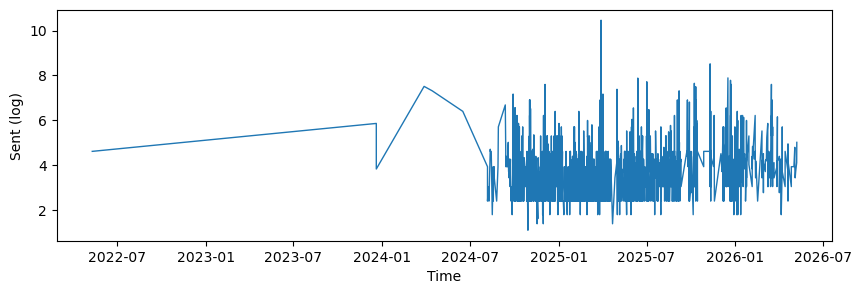

In [19]:
# get visuals of each txn_type over time
# start with money sent over time
sent = df[df['txn_type'] == 'sent']
time = sent.timestamp
plt.figure(figsize=(10,3))
plt.plot(time, np.log1p(sent.amount), linewidth=1)
plt.ylabel('Sent (log)')
plt.xlabel('Time');

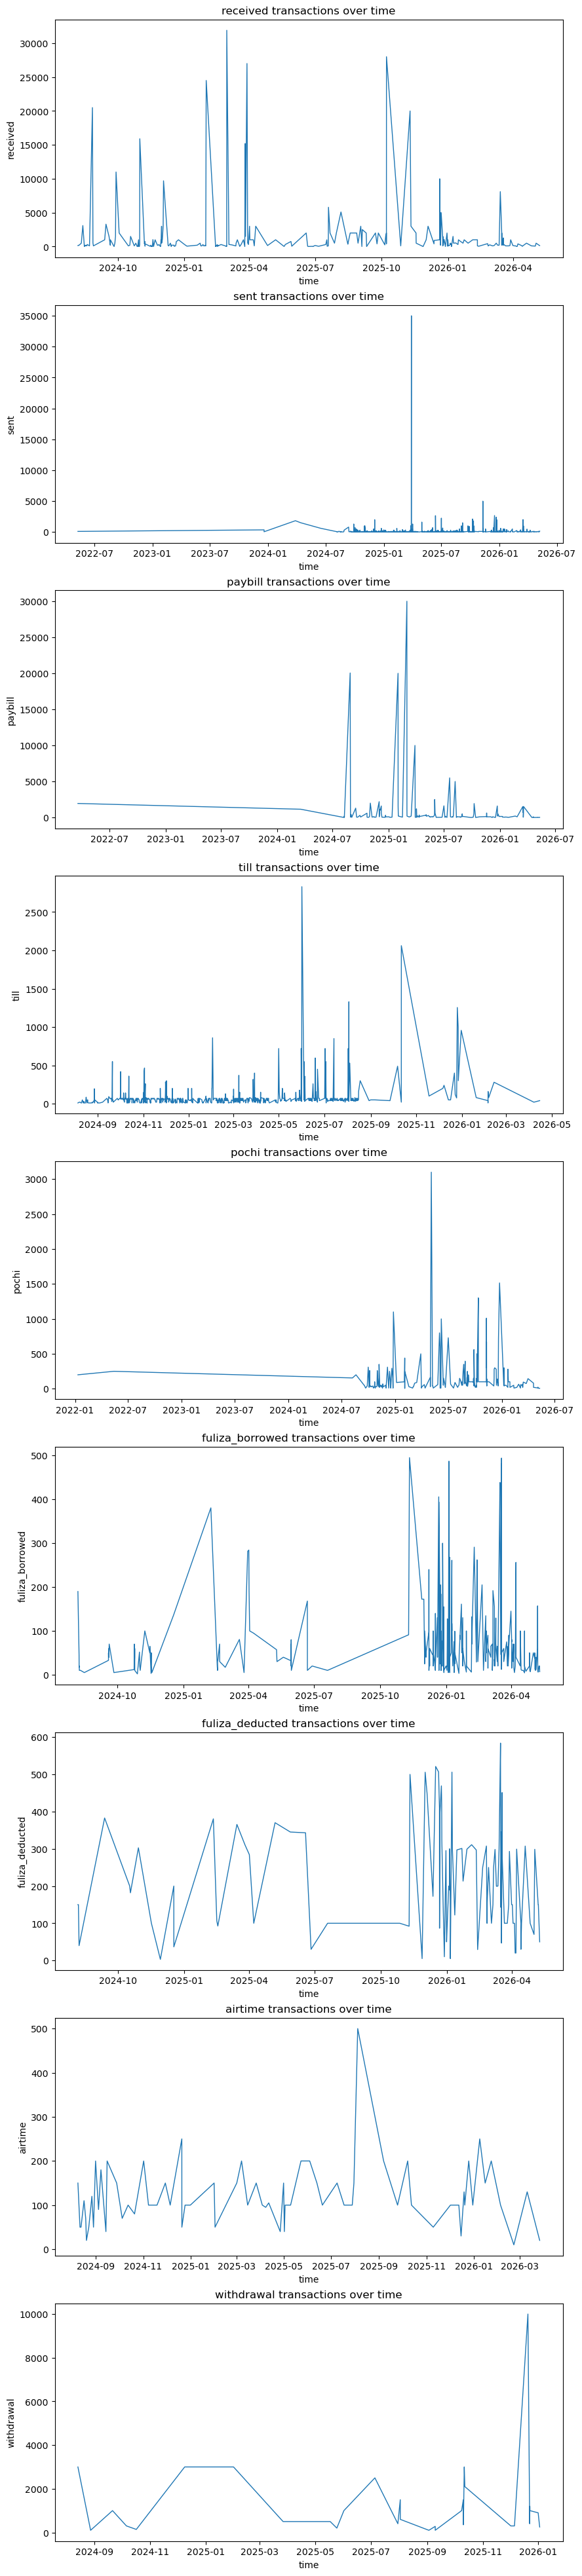

In [21]:
# get visuals of each txn_type over time
fig, axes = plt.subplots(9, 1, figsize=(10,50))
txns = ['received',  'sent', 'paybill', 'till', 'pochi', 'fuliza_borrowed', 'fuliza_deducted', 
         'airtime', 'withdrawal']

for ax, txn in zip(axes, txns):
    txn_df = df[df['txn_type'] == txn]
    time = txn_df.timestamp
    # plots
    ax.plot(time, txn_df['amount'], linewidth=1)
    ax.set_title(f"{txn} transactions over time")
    ax.set_ylabel(f"{txn}")
    ax.set_xlabel('time');

In [23]:
# model for spending predictions
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor

# prepare spending monthly features
def prepare_monthly_data(df:pd.DataFrame) -> pd.DataFrame:
    outflows = df[df['txn_type'].isin(['sent', 'paybill', 'till', 'pochi',
                                       'fuliza_borrowed', 'airtime', 'withdrawal'])].copy()

    # map transcations into readable categories
    type_to_category = {
        'sent': 'personal_transfers',
        'paybill': 'paybill',
        'till': 'till_shopping',
        'airtime': 'airtime',
        'pochi': 'pochi',
        'withdrawal': 'withdrawal',
        'fuliza_borrowed': 'fuliza'
    }

    outflows['category'] = outflows['txn_type'].map(type_to_category)
    outflows['month'] = outflows['timestamp'].dt.to_period('M')

    # pivot: months=rows, categories=columns
    monthly = outflows.pivot_table(
        index = 'month',
        columns = 'category',
        values = 'amount',
        aggfunc = 'sum'
    ).fillna(0)

    # add total spending column
    monthly['total'] = monthly.sum(axis=1)

    # add month level features
    monthly_reset = monthly.reset_index()
    monthly_reset['month_num'] = range(len(monthly_reset))
    monthly_reset['month_of_yr'] = monthly_reset['month'].dt.month

    print(f"Monthly data {len(monthly_reset)} months")
    print(f"From {monthly_reset['month'].min()}")
    print(f"To {monthly_reset['month'].max()}")
    print(f"\nCategories found {list(monthly.columns)}")

    return monthly_reset
    
pivot_df = prepare_monthly_data(df)
pivot_df.head(5)

Monthly data 29 months
From 2022-01
To 2026-05

Categories found ['airtime', 'fuliza', 'paybill', 'personal_transfers', 'pochi', 'till_shopping', 'withdrawal', 'total']


category,month,airtime,fuliza,paybill,personal_transfers,pochi,till_shopping,withdrawal,total,month_num,month_of_yr
0,2022-01,0.0,0.0,0.0,0.0,200.0,0.0,0.0,200.0,0,1
1,2022-03,0.0,0.0,1950.0,0.0,0.0,0.0,0.0,1950.0,1,3
2,2022-05,0.0,0.0,0.0,200.0,250.0,0.0,0.0,450.0,2,5
3,2023-12,0.0,0.0,0.0,395.0,0.0,0.0,0.0,395.0,3,12
4,2024-03,0.0,0.0,1150.0,1830.0,0.0,0.0,0.0,2980.0,4,3


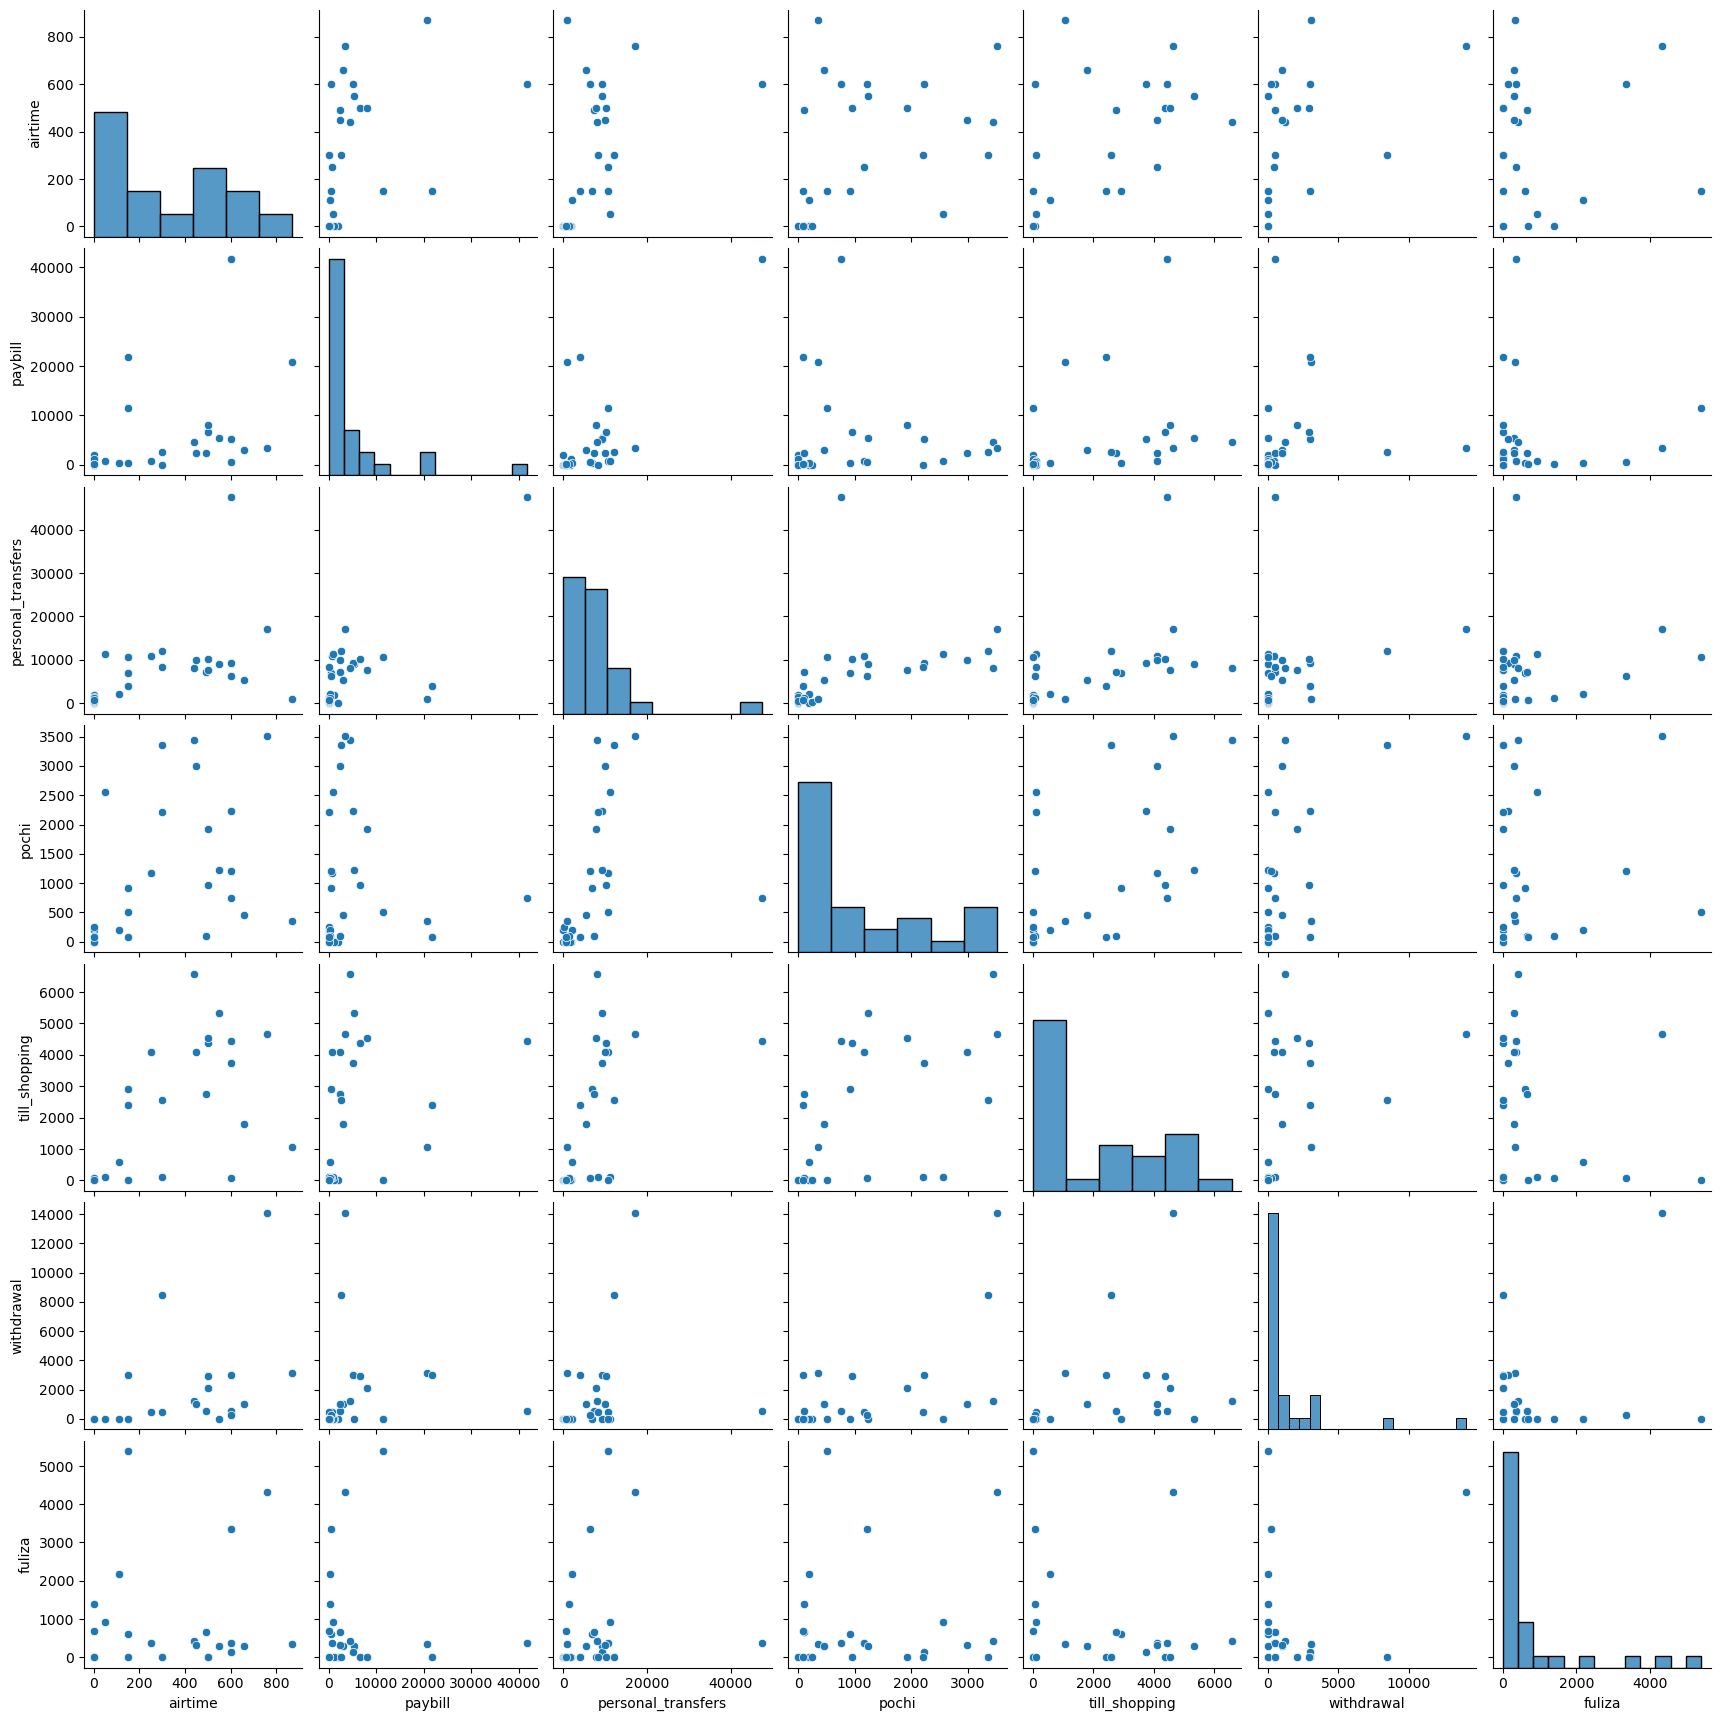

In [25]:
# is there any relationship between the transactions
categories = ['airtime', 'paybill', 'personal_transfers', 'pochi', 'till_shopping', 'withdrawal', 'fuliza']
sns.pairplot(pivot_df[categories], palette='flare')

In [27]:
# ── Step 2: Build lag features ────────────────────────────────
# "What did I spend last month and the month before?"
# These become the model's input features
def add_lag_features(df:pd.DataFrame, target_col:str, lags:list[1,2,3]) -> pd.DataFrame:
    df = df.copy()
    for lag in lags:
        df[f'{target_col}_lag{lag}'] = df[target_col].shift(lag)

    # Rolling average — smooths out one-off spikes
    df[f'{target_col}_rolling3'] = df[target_col].shift(1).rolling(3).mean()
    df[f"{target_col}_rolling6"] = df[target_col].shift(1).rolling(6).mean()

    # Trend — is spending going up or down?
    df[f'{target_col}_trend'] = df[target_col].diff()

    return df
    
# Step 3: train and predict
def train_and_predict(monthly_df:pd.DataFrame, target:str = 'total') -> dict:
    # train a model that predicts next month's spending, returns prediction and model evaluation
    df = add_lag_features(monthly_df, target, lags=[1,2,3])
    df = df.dropna()  # drop rows where lag is NaN

    if len(df) < 4:
        print(f"Not enough months of data to train the model '{target}' reliably")
        print(f"Need at least 6 months, have {len(df)}")
        # fall back to simple average
        avg = monthly_df[target].mean()
        return {
            'target':     target,
            'prediction': round(avg, 2),
            'method':     'historical average',
            'mae':         None,
            'history':     monthly_df[['month', target]].copy()
        }
    feature_cols = [
        'month_num', 'month_of_yr', f'{target}_lag1', f'{target}_lag2', f'{target}_lag3',
        f'{target}_rolling3', f'{target}_rolling6', f'{target}_trend'
    ]

    # only choose columns that exists
    feature_cols = [c for c in feature_cols if c in df.columns ]

    X = df[feature_cols]
    y = df[target]

    # Train on all but last month, test on last month
    X_train, X_test = X.iloc[:-1], X.iloc[[-1]]
    y_train, y_test = y.iloc[:-1], y.iloc[-1]

    # use GradientBoostingRegressor: Handles small datasets well
    model = GradientBoostingRegressor(
        n_estimators = 100,
        max_depth = 3,
        learning_rate = 0.1,
        random_state = 42
    )
    model.fit(X_train, y_train)

    #  evaluate model on last know month
    y_pred_last = model.predict(X_test)[0]
    mae = abs(y_pred_last - y_test)

    # now predict next month
    next_row = X_test.copy()
    next_row['month_num']          = next_row['month_num'] + 1
    next_row['month_of_yr']        = (next_row['month_of_yr'] % 12) + 1
    next_row[f'{target}_lag2']     = next_row[f'{target}_lag1']
    next_row[f'{target}_lag3']     = next_row[f'{target}_lag2']
    next_row[f'{target}_lag1']     = y_test
    next_row[f'{target}_rolling3'] = y.tail(3).mean()
    next_row[f'{target}_rolling6'] = y.tail(6).mean()
    next_row[f'{target}_trend']    = y_test - y.iloc[-2]

    next_prediction = max(model.predict(next_row)[0], 0)

    return {
    'target':     target,
    'prediction': round(next_prediction, 2),
    'last_month': round(float(y_test), 2),
    'mae':        round(mae, 2),
    'method':     'gradient_boosting',
    #'history':    monthly_df[['month', target]].copy(),
    #'model':      model
    }



In [29]:
def forecast_next_month(df:pd.DataFrame):
    monthly_df = prepare_monthly_data(df)

    # Categories to forecast
    categories = [c for c in monthly_df.columns
                  if c not in ['month', 'month_num', 'month_of_yr']]

    print("\n" + "="*55)
    print("   NEXT MONTH SPENDING FORECAST")
    print("="*55)

    results = {}
    for cat in categories:
        result = train_and_predict(monthly_df, target=cat)
        results[cat] = result

        if cat == 'total':
            print(f"\n💰 TOTAL SPENDING")
        else:
            print(f"\n📊 {cat.upper().replace('_',' ')}")

        print(f"   Last month actual : Ksh {result['last_month']:>10,.2f}")
        print(f"   Next month forecast: Ksh {result['prediction']:>10,.2f}")

        if result['mae'] is not None:
            print(f"   Model error (MAE) : Ksh {result['mae']:>10,.2f}")

        if result['method'] == 'historical_average':
            print(f"   ⚠ Based on average (need more data for ML)")

    #return results# monthly_df


In [31]:
forecast_next_month(df)

Monthly data 29 months
From 2022-01
To 2026-05

Categories found ['airtime', 'fuliza', 'paybill', 'personal_transfers', 'pochi', 'till_shopping', 'withdrawal', 'total']

   NEXT MONTH SPENDING FORECAST

📊 AIRTIME
   Last month actual : Ksh       0.00
   Next month forecast: Ksh      40.12
   Model error (MAE) : Ksh      47.52

📊 FULIZA
   Last month actual : Ksh     691.73
   Next month forecast: Ksh   2,282.71
   Model error (MAE) : Ksh   2,899.82

📊 PAYBILL
   Last month actual : Ksh     140.00
   Next month forecast: Ksh     382.88
   Model error (MAE) : Ksh     274.89

📊 PERSONAL TRANSFERS
   Last month actual : Ksh     650.00
   Next month forecast: Ksh   2,047.51
   Model error (MAE) : Ksh   4,754.18

📊 POCHI
   Last month actual : Ksh      89.00
   Next month forecast: Ksh     228.28
   Model error (MAE) : Ksh      77.26

📊 TILL SHOPPING
   Last month actual : Ksh       0.00
   Next month forecast: Ksh       0.00
   Model error (MAE) : Ksh      11.08

📊 WITHDRAWAL
   Last month 

In [33]:
def prepare_data(df:pd.DataFrame):
    outflows = df[df['txn_type'].isin(['sent', 'paybill', 'till', 'pochi', 'airtime', 'withdrawal'])].copy()

    # map transcations into readable categories
    type_to_category = {
        'sent': 'personal_transfers',
        'paybill': 'paybill',
        'till': 'till_shopping',
        'airtime': 'airtime',
        'pochi': 'pochi',
        'withdrawal': 'withdrawal'
    }

    outflows['category'] = outflows['txn_type'].map(type_to_category)
    outflows['time'] = outflows['timestamp']

    # pivot: months=rows, categories=columns
    monthly = outflows.pivot_table(
        index = 'time',
        columns = 'category',
        values = 'amount',
        aggfunc = 'sum'
    ).fillna(0)

    # add total spending column
    #monthly['total'] = monthly.sum(axis=1)

    # add month level features
    monthly_reset = monthly.reset_index()

    return monthly_reset

prepare_data(df)

category,time,airtime,paybill,personal_transfers,pochi,till_shopping,withdrawal
0,2022-01-10 17:41:48.209,0.0,0.0,0.0,200.0,0.0,0.0
1,2022-03-19 08:56:05.063,0.0,1950.0,0.0,0.0,0.0,0.0
2,2022-05-10 18:56:28.832,0.0,0.0,100.0,0.0,0.0,0.0
3,2022-05-10 19:20:32.346,0.0,0.0,100.0,0.0,0.0,0.0
4,2022-05-13 18:35:03.111,0.0,0.0,0.0,250.0,0.0,0.0
...,...,...,...,...,...,...,...
3072,2026-05-08 02:15:39.391,0.0,10.0,0.0,0.0,0.0,0.0
3073,2026-05-08 13:53:19.899,0.0,0.0,0.0,6.0,0.0,0.0
3074,2026-05-09 19:27:18.783,0.0,20.0,0.0,0.0,0.0,0.0
3075,2026-05-10 14:04:27.463,0.0,20.0,0.0,0.0,0.0,0.0


In [39]:
targets = ['personal_transfers', 'paybill', 'till_shopping', 'pochi', 'airtime', 'withdrawal']
data = prepare_data(df)
target_dfs = {}

for target in targets:
    if target not in data.columns:
        print(f"{target} not found in columns - skipping")
    target_df = data[['time', target]].copy()
    target_df = target_df[target_df[target] != 0].reset_index(drop=True)
    target_dfs[target] = target_df
   # print(target_df)

target_dfs['paybill'].head(5)

category,time,paybill
0,2022-03-19 08:56:05.063,1950.0
1,2024-03-18 11:51:16.453,1150.0
2,2024-08-05 14:34:43.005,20.0
3,2024-08-07 10:37:46.346,30.0
4,2024-08-08 09:28:05.288,200.0


In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

def r2_safe(y_true, y_pred):
    """
    R² that never returns NaN.
    Falls back to MAE-based score when R² is undefined.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    if len(y_true) < 2:
        return None  # truly can't score 1 sample

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)

    if ss_tot == 0:
            # All test values identical — score based on how close predictions are
            # 1.0 = perfect, 0.0 = off by the mean value
        mean_val = y_true.mean()
        if mean_val == 0:
            return 1.0 if ss_res == 0 else 0.0
        return max(0, 1 - (np.sqrt(ss_res / len(y_true)) / mean_val))

    return 1 - (ss_res / ss_tot)
    
def train_test(df):
    data = prepare_data(df)
    
    targets = ['personal_transfers', 'paybill', 'till_shopping', 
               'pochi', 'airtime', 'withdrawal']
    model = XGBRegressor(
            n_estimators=100,
            max_depth=5,       # prevent overfitting on small data
            max_leaves=3,
            #min_samples_leaf=4,
            learning_rate=0.3,
            random_state=42
            )
    
    scores      = []
    predictions = {}

    for target in targets:
        if target not in data.columns:
            print(f"⚠  '{target}' not found — skipping")
            continue

        # ── Build target df ───────────────────────────────
        target_df = data[['time', target]].copy()

        # ── Sort by time ──────────────────────────────────
        target_df = target_df.sort_values('time').reset_index(drop=True)
        
        # ── Create lag features ───────────────────────────
        target_df['lag1'] = target_df[target].shift(1)
        target_df['lag2'] = target_df[target].shift(2)
        target_df['lag3'] = target_df[target].shift(3)

        # Rolling behavior
        target_df['rolling_mean_3'] = (target_df[target].rolling(3).mean())          
        target_df['rolling_std_3'] = (target_df[target].rolling(3).std())

        # Optional calendar info
        target_df['year'] = target_df['time'].dt.year # helps with trend
        target_df['month'] = target_df['time'].dt.month
        target_df['dayofweek'] = target_df['time'].dt.dayofweek
        target_df['hour']  = target_df['time'].dt.hour
        # ── Remove NaNs caused by shifting ────────────────
        target_df = target_df.dropna().reset_index(drop=True)
        
        n = len(target_df)
        # ── Guard: need at least 5 rows to split meaningfully ─
        if n < 5:
            avg = target_df[target].mean()
            print(f"{target:<22} ⚠  only {n} rows — using average: "
                  f"Ksh {avg:,.2f}")
            predictions[target] = round(avg, 2)
            scores.append({'target': target, 'score': None, 
                           'mae': None, 'n': n})
            continue

        # ── Features:
        features = target_df[['lag1', 'lag2','lag3','rolling_mean_3','rolling_std_3','year','month',
                             'dayofweek', 'hour']].values

        model_target = target_df[target].values

        # ── 80/20 split — ensure at least 1 row in test ──
        train_len = min(max(int(n * 0.8), 1), n - 1)

        X_train, X_test = features[:train_len],     features[train_len:]
        y_train, y_test = model_target[:train_len], model_target[train_len:]

        # ── Train ─────────────────────────────────────────
        model.fit(X_train, y_train)

        # ── Evaluate ──────────────────────────────────────
        y_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)
        score  = r2_safe(y_test, y_pred)
        mae    = mean_absolute_error(y_test, y_pred)

        # ── Predict next month ────────────────────────────
        last_time  = target_df['time'].iloc[-1]
        next_month = last_time + pd.DateOffset(months=1)
        last_row = target_df.iloc[-1]
        next_features = np.array([[
            last_row['lag1'],
            last_row['lag2'],
            last_row['lag3'],
            last_row['rolling_mean_3'],
            last_row['rolling_std_3'],
            next_month.year,
            next_month.month,
            next_month.dayofweek,
            next_month.hour
        ]])
    

        next_pred = max(model.predict(next_features)[0],0)
        predictions[target] = round(next_pred, 2)

        scores.append({
            'target': target, 
            'score':  round(score, 3),
            'mae':    round(mae, 2),
            'n':      n
        })

        print(f"{target:<22} score: {score:>7.3f}   "
              f"MAE: Ksh {mae:>8,.2f}   "
              f"rows: {n:>3}   "
              f"next month: Ksh {next_pred:>8,.2f}")

    # ── Summary ───────────────────────────────────────────────
    print("\n" + "="*55)
    print("   NEXT MONTH FORECAST SUMMARY")
    print("="*55)
    total = 0
    for target, pred in predictions.items():
        print(f"   {target:<22} Ksh {pred:>10,.2f}")
        total += pred
    print(f"{'─'*55}")
    print(f"   {'TOTAL':<22} Ksh {total:>10,.2f}")
    print("="*55)

    return scores, predictions



In [55]:
print(train_test(df))

personal_transfers     score:   0.727   MAE: Ksh    46.58   rows: 3074   next month: Ksh     6.10
paybill                score:   0.734   MAE: Ksh    21.94   rows: 3074   next month: Ksh     9.21
till_shopping          score:   0.803   MAE: Ksh     8.37   rows: 3074   next month: Ksh     0.57
pochi                  score:   0.856   MAE: Ksh    10.25   rows: 3074   next month: Ksh     0.12
airtime                score:   0.962   MAE: Ksh     0.58   rows: 3074   next month: Ksh     0.03
withdrawal             score:   0.568   MAE: Ksh    18.74   rows: 3074   next month: Ksh     0.06

   NEXT MONTH FORECAST SUMMARY
   personal_transfers     Ksh       6.10
   paybill                Ksh       9.21
   till_shopping          Ksh       0.57
   pochi                  Ksh       0.12
   airtime                Ksh       0.03
   withdrawal             Ksh       0.06
───────────────────────────────────────────────────────
   TOTAL                  Ksh      16.09
([{'target': 'personal_transfers', 's

In [85]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
def grid_search(df):
    data = prepare_data(df)
    
    targets = ['personal_transfers', 'paybill', 'till_shopping', 
               'pochi', 'airtime', 'withdrawal']
    model = XGBRegressor(random_state=42)

    param_grid = {
            'n_estimators':[50,100,150],
            'max_depth': [3,4,5,6,7],
            'max_leaves': [2,3,4,5],
            'learning_rate': [0.1,0.2,0.3,0.4,0.5]
        }
    kfold = StratifiedKFold(5)

    for target in targets:
        if target not in data.columns:
            print(f"⚠  '{target}' not found — skipping")
            continue

        # ── Build target df ───────────────────────────────
        target_df = data[['time', target]].copy()

        # ── Sort by time ──────────────────────────────────
        target_df = target_df.sort_values('time').reset_index(drop=True)
        
        # ── Create lag features ───────────────────────────
        target_df['lag1'] = target_df[target].shift(1)
        target_df['lag2'] = target_df[target].shift(2)
        target_df['lag3'] = target_df[target].shift(3)

        # Rolling behavior
        target_df['rolling_mean_3'] = (target_df[target].rolling(3).mean())          
        target_df['rolling_std_3'] = (target_df[target].rolling(3).std())

        # Optional calendar info
        target_df['year'] = target_df['time'].dt.year # helps with trend
        target_df['month'] = target_df['time'].dt.month
        target_df['dayofweek'] = target_df['time'].dt.dayofweek
        target_df['hour']  = target_df['time'].dt.hour
        # ── Remove NaNs caused by shifting ────────────────
        target_df = target_df.dropna().reset_index(drop=True)
        
        n = len(target_df)

        # ── Features:
        features = target_df[['lag1', 'lag2','lag3','rolling_mean_3','rolling_std_3','year','month',
                             'dayofweek', 'hour']].values

        model_target = target_df[target].values
        
        

        # ── 80/20 split — ensure at least 1 row in test ──
        train_len = min(max(int(n * 0.8), 1), n - 1)

        X_train, X_test = features[:train_len],     features[train_len:]
        y_train, y_test = model_target[:train_len], model_target[train_len:]

        # ── grid search ─────────────────────────────────────────
        gs = GridSearchCV(model, param_grid, cv=kfold)
        gs.fit(X_train, y_train)

        print("{} best params: {}".format(target, gs.best_params_))
        print("{} best scores: {:.3f}".format(target, gs.best_score_))
        print("{} test score: {:.3f}".format(target, gs.score(X_test, y_test)))

In [87]:
grid_search(df)

personal_transfers best params: {'learning_rate': 0.4, 'max_depth': 3, 'max_leaves': 4, 'n_estimators': 150}
personal_transfers best scores: 0.644
personal_transfers test score: 0.698
paybill best params: {'learning_rate': 0.2, 'max_depth': 3, 'max_leaves': 4, 'n_estimators': 150}
paybill best scores: 0.483
paybill test score: 0.823
till_shopping best params: {'learning_rate': 0.1, 'max_depth': 3, 'max_leaves': 4, 'n_estimators': 150}
till_shopping best scores: 0.284
till_shopping test score: 0.867
pochi best params: {'learning_rate': 0.4, 'max_depth': 3, 'max_leaves': 3, 'n_estimators': 150}
pochi best scores: 0.812
pochi test score: 0.889
airtime best params: {'learning_rate': 0.5, 'max_depth': 3, 'max_leaves': 3, 'n_estimators': 150}
airtime best scores: 0.750
airtime test score: 0.984
withdrawal best params: {'learning_rate': 0.4, 'max_depth': 4, 'max_leaves': 5, 'n_estimators': 150}
withdrawal best scores: 0.943
withdrawal test score: 0.577


In [49]:
from xgboost import XGBRegressor
def plot_pred(df):
    data = prepare_data(df)
    
    targets = ['personal_transfers', 'paybill', 'till_shopping', 
               'pochi', 'airtime', 'withdrawal']
    model = XGBRegressor(
            n_estimators=100,
            max_depth=5,       # prevent overfitting on small data
            max_leaves=3,
            #min_samples_leaf=4,
            learning_rate=0.3,
            random_state=42
            )
    
    target_dfs = {}

    for target in targets:
        if target not in data.columns:
            print(f"⚠  '{target}' not found — skipping")
            continue

        # ── Build target df ───────────────────────────────
        target_df = data[['time', target]].copy()

        # keep only rows where target actually existed
        target_df = target_df[target_df[target] != 0]
        
        # ── Sort by time ──────────────────────────────────
        #target_df = target_df.sort_values('time').reset_index(drop=True)
        target_df = (target_df.set_index('time').resample('D')[target].sum().reset_index())
        
        # crete a copy of original target and time
        original_time = target_df['time'].copy()
        original_target = target_df[target].copy()
        
        # ── Create lag features ───────────────────────────
        target_df['lag1'] = target_df[target].shift(1)
        target_df['lag2'] = target_df[target].shift(2)
        target_df['lag3'] = target_df[target].shift(3)

        # Rolling behavior
        target_df['rolling_mean_3'] = (target_df[target].rolling(3).mean())          
        target_df['rolling_std_3'] = (target_df[target].rolling(3).std())

        # Optional calendar info
        target_df['year'] = target_df['time'].dt.year # helps with trend
        target_df['month'] = target_df['time'].dt.month
        target_df['dayofweek'] = target_df['time'].dt.dayofweek
        target_df['hour']  = target_df['time'].dt.hour
        # ── Remove NaNs caused by shifting ────────────────
        target_df = target_df.dropna().reset_index(drop=True)
        
        target_dfs[target] = target_df
        
        n = len(target_df)

        # ── Features:
        features = target_df[['lag1', 'lag2','lag3','rolling_mean_3','rolling_std_3','year','month',
                             'dayofweek', 'hour']].values


        model_target = target_df[target].values

        # ── 80/20 split — ensure at least 1 row in test ──
        train_len = min(max(int(n * 0.8), 1), n - 1)
        # split original target
        original_target_train =  original_target[:train_len]
        original_target_test = original_target[train_len:]
        
        X_train, X_test = features[:train_len],     features[train_len:]
        y_train, y_test = model_target[:train_len], model_target[train_len:]
        #print(len(X_test))
        #print(len(y_test))
        # ── Train ─────────────────────────────────────────
        model.fit(X_train, y_train)

        # ── Evaluate ──────────────────────────────────────
        y_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)

        fig, ax = plt.subplots(figsize=(12, 5))
        # split time into train and test time
        time = target_dfs[target].time
        train_time = time.iloc[:train_len]
        test_time = time.iloc[train_len:]
        
        # split original time
        original_time_train =  original_time.iloc[:train_len]
        original_time_test = original_time.iloc[train_len:]
        #print(f'original_test_time {len(original_time_test)}')
        #print(f'y_pred {len(y_pred)}')
        # create plots
        ax.plot(train_time, y_train, label='Train')
        ax.plot(test_time, y_test, label='Test')
        ax.plot(train_time, y_train_pred, '--', label='Prediction train')
        ax.plot(test_time, y_pred, '--', label='Prediction test')
        ax.set_title(f"{target} predictions")
        ax.set_ylabel(f"{target}")
        ax.set_xlabel('time')
        ax.legend(loc='best')
        plt.xticks(rotation=45)
        plt.tight_layout();
        

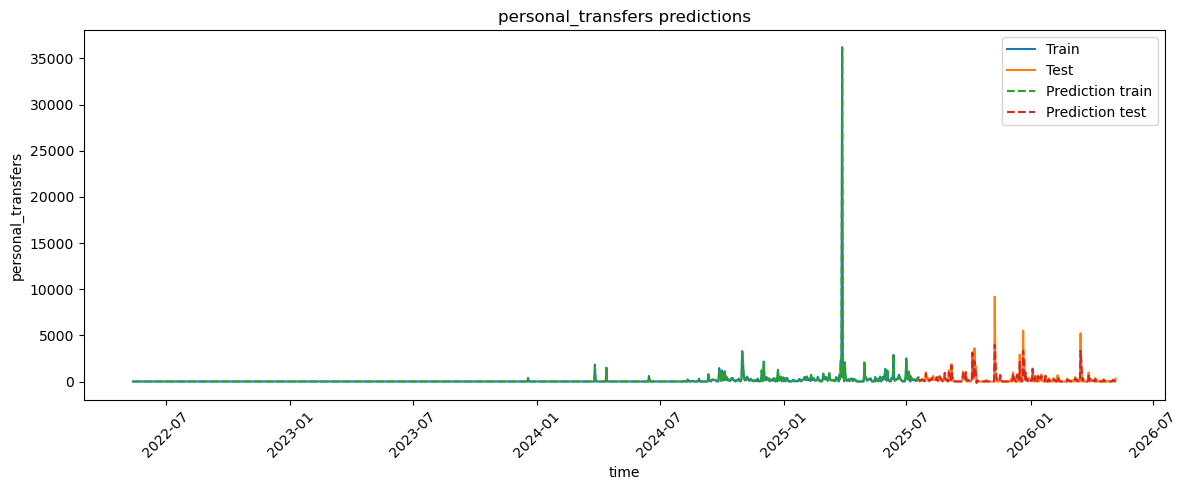

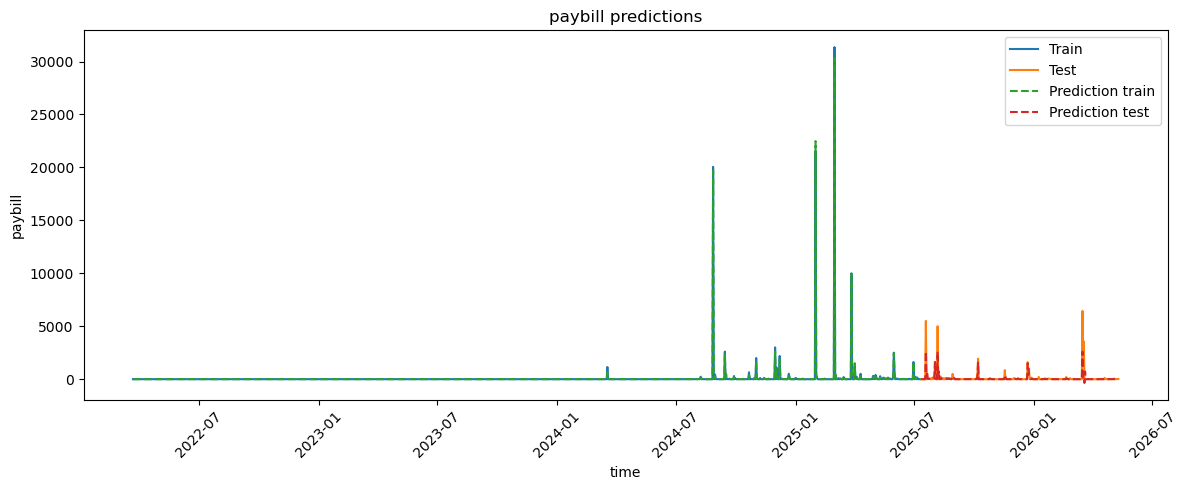

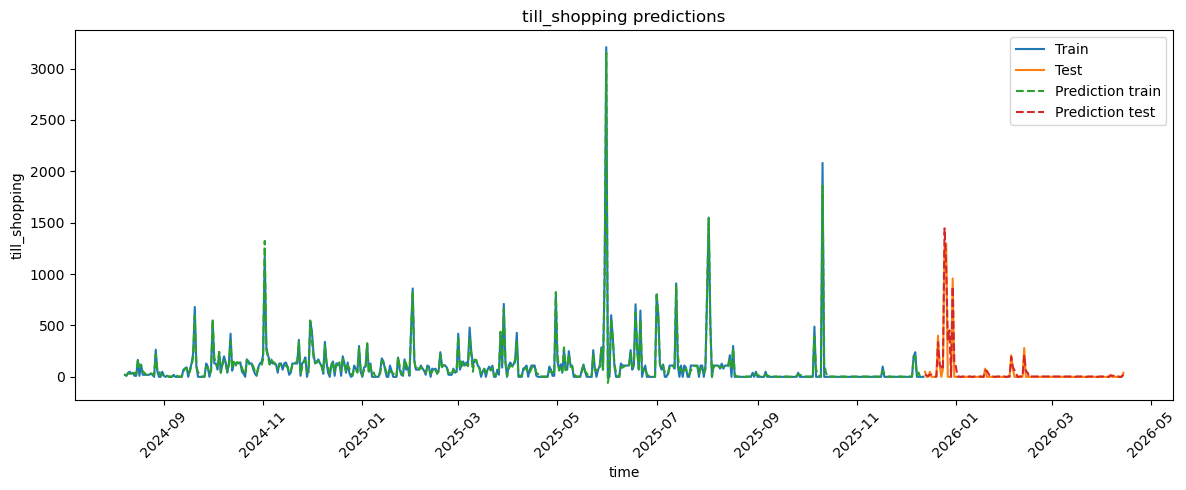

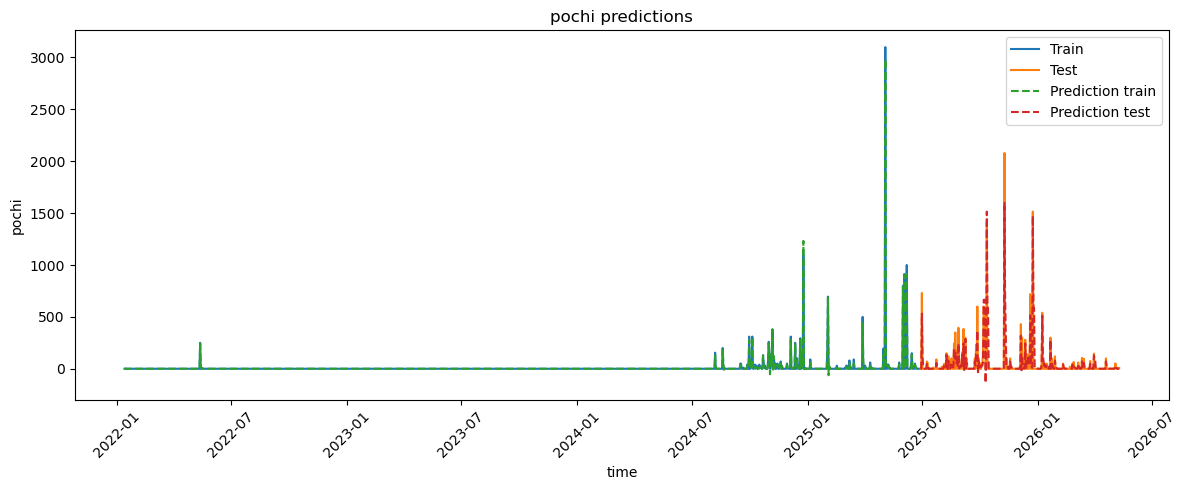

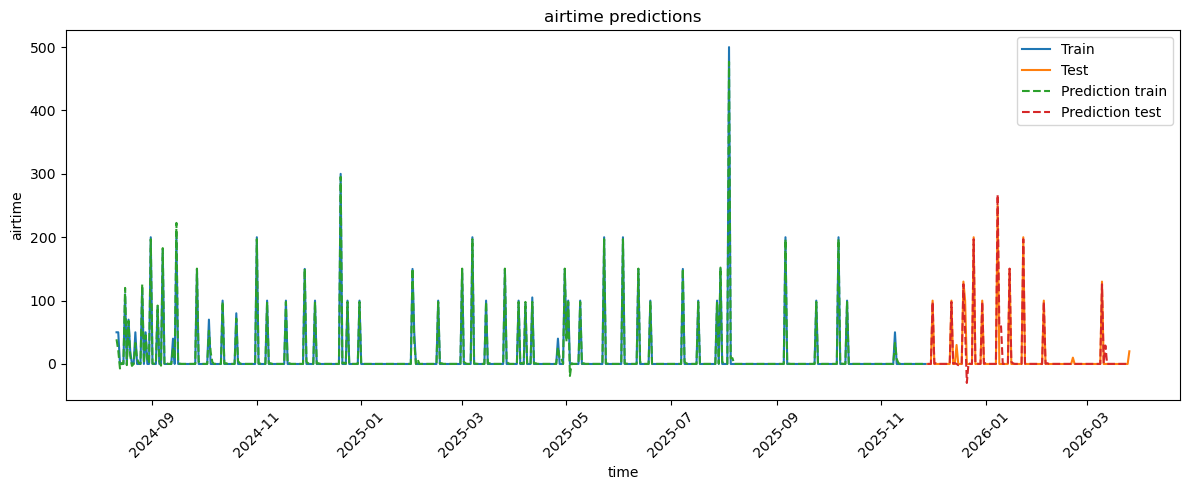

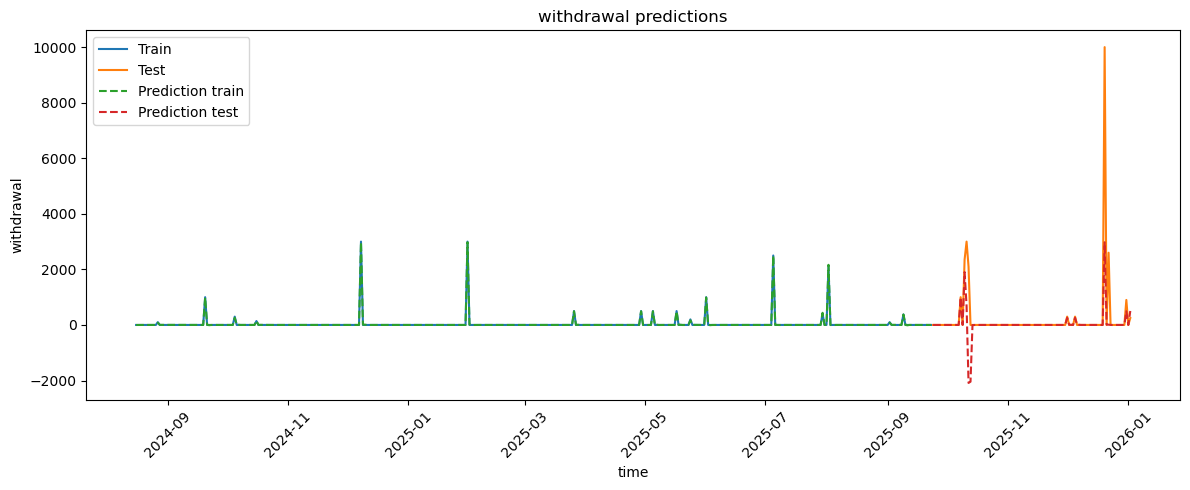

In [51]:
plot_pred(df)

In [47]:
from xgboost import XGBRegressor
help(XGBRegressor)

Help on class XGBRegressor in module xgboost.sklearn:

class XGBRegressor(sklearn.base.RegressorMixin, XGBModel)
 |  XGBRegressor(*, objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'reg:squarederror', **kwargs: Any) -> None
 |
 |  Implementation of the scikit-learn API for XGBoost regression.
 |  See :doc:`/python/sklearn_estimator` for more information.
 |
 |  Parameters
 |  ----------
 |
 |      n_estimators : typing.Optional[int]
 |          Number of gradient boosted trees.  Equivalent to number of boosting
 |          rounds.
 |
 |      max_depth :  typing.Optional[int]
 |
 |          Maximum tree depth for base learners.
 |
 |      max_leaves : typing.Optional[int]
 |
 |          Maximum number of leaves; 0 indicates no limit.
 |
 |      max_bin : typing.Optional[int]
 |
 |          If using histogram-based algorithm, maximum number of bins per feature
 |
 |      grow_policy : typing.Optional[str]
 |
 |  